# **AI-Powered Plant Disease Detection and Treatment Recommendation**
using Deep Learning and Hugging Face Generative AI

## Dataset - loading & preprocessing:

#### Create a new token from [Kaggle](https://kagle.com):

In [ ]:
# --- Copy the API token and run the cell below to read the token automatically: ---

!mkdir -p ~/.kaggle && echo KGAT_8079de38373b9939a5bbe5456dbda586 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [ ]:
# --- Download and unzip the dataset ---

!kaggle datasets download -d vipoooool/new-plant-diseases-dataset
!unzip -q new-plant-diseases-dataset.zip -d plant_disease_data

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
new-plant-diseases-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace plant_disease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Apple___Apple_scab/00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
# --- To confirm successful loading of the dataset ---

import os
base_dir = "/content/plant_disease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
print(os.listdir(base_dir))
print("Classes:", len(os.listdir(os.path.join(base_dir, "train"))))

['train', 'valid']
Classes: 38


## Re-splitting dataset into 70/15/15 (Train/Val/Test)

The original dataset ships with a pre-defined `train`/`valid` split (~80/20), which the project documentation requires to be 70% Training / 15% Validation / 15% Testing. The cells below merge `train` and `valid` into one pool per class, then re-split into the exact required proportions.

In [ ]:
!pip install -q split-folders

import shutil

# Original dataset's pre-existing train/valid folders (source for merging)
old_train_dir = os.path.join(base_dir, "train")
old_valid_dir = os.path.join(base_dir, "valid")

merged_dir = "/content/merged_dataset"
os.makedirs(merged_dir, exist_ok=True)

classes = os.listdir(old_train_dir)
for cls in classes:
    os.makedirs(os.path.join(merged_dir, cls), exist_ok=True)
    # copy train images
    for f in os.listdir(os.path.join(old_train_dir, cls)):
        shutil.copy(os.path.join(old_train_dir, cls, f), os.path.join(merged_dir, cls, f))
    # copy valid images
    for f in os.listdir(os.path.join(old_valid_dir, cls)):
        shutil.copy(os.path.join(old_valid_dir, cls, f), os.path.join(merged_dir, cls, f))

print("Merge complete. Class count:", len(os.listdir(merged_dir)))

In [13]:
import splitfolders

splitfolders.ratio(merged_dir, output="/content/split_dataset", seed=42, ratio=(0.7, 0.15, 0.15))

split_base = "/content/split_dataset"
new_train_dir = os.path.join(split_base, "train")
new_val_dir = os.path.join(split_base, "val")
new_test_dir = os.path.join(split_base, "test")

print("Train:", sum(len(os.listdir(os.path.join(new_train_dir, c))) for c in os.listdir(new_train_dir)))
print("Val:", sum(len(os.listdir(os.path.join(new_val_dir, c))) for c in os.listdir(new_val_dir)))
print("Test:", sum(len(os.listdir(os.path.join(new_test_dir, c))) for c in os.listdir(new_test_dir)))

Copying files: 87867 files [00:18, 4668.30 files/s]


Train: 61490
Val: 13164
Test: 13213


Scan and remove any unreadable images from your split dataset before training:

In [25]:
from PIL import Image

def clean_corrupt_images(directory):
    removed = 0
    for root, dirs, files in os.walk(directory):
        for fname in files:
            fpath = os.path.join(root, fname)
            try:
                with Image.open(fpath) as img:
                    img.verify()
            except Exception:
                os.remove(fpath)
                removed += 1
    return removed

for split_name in ['train', 'val', 'test']:
    d = os.path.join(split_base, split_name)
    removed = clean_corrupt_images(d)
    print(f"{split_name}: removed {removed} corrupt image(s)")

train: removed 1 corrupt image(s)
val: removed 0 corrupt image(s)
test: removed 0 corrupt image(s)


#### Preprocessing - Data generators:

In [26]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = os.path.join(split_base, "train")
valid_dir = os.path.join(split_base, "val")
test_dir = os.path.join(split_base, "test")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2]
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = len(train_generator.class_indices)
print(f"Number of classes: {num_classes}")

Found 61489 images belonging to 38 classes.
Found 13164 images belonging to 38 classes.
Found 13213 images belonging to 38 classes.
Number of classes: 38


## Baseline CNN model:

Build the model:

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Dense, Flatten
from tensorflow.keras.optimizers import Adam

baseline_model = Sequential([
    Conv2D(32, (3,3), activation = 'relu', input_shape = (224,224,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation = 'relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation = 'relu'),
    MaxPooling2D(2,2),
    Dropout(0.3),
    Flatten(),
    Dense(256, activation = 'relu'),
    Dropout(0.4),
    Dense(num_classes, activation = 'softmax')
])

baseline_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,254,438 (84.89 MB)

 Trainable params: 22,254,438 (84.89 MB)

 Non-trainable params: 0 (0.00 B)

Train the model:

In [16]:
history = baseline_model.fit(
    train_generator,
    validation_data = val_generator,
    epochs = 6,
    steps_per_epoch = min(500, train_generator.samples // BATCH_SIZE),
    validation_steps = min(100, val_generator.samples // BATCH_SIZE)
)

Epoch 1/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 244s 469ms/step - accuracy: 0.2244 - loss: 2.8261 - val_accuracy: 0.3594 - val_loss: 2.2699
Epoch 2/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 226s 453ms/step - accuracy: 0.4920 - loss: 1.7052 - val_accuracy: 0.5747 - val_loss: 1.4013
Epoch 3/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 228s 457ms/step - accuracy: 0.6023 - loss: 1.2997 - val_accuracy: 0.6591 - val_loss: 1.1259
Epoch 4/6
422/500 ━━━━━━━━━━━━━━━━━━━━ 35s 450ms/step - accuracy: 0.6548 - loss: 1.1209

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 194s 389ms/step - accuracy: 0.6618 - loss: 1.0990 - val_accuracy: 0.7306 - val_loss: 0.8717
Epoch 5/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 263s 525ms/step - accuracy: 0.7002 - loss: 0.9798 - val_accuracy: 0.8172 - val_loss: 0.6290
Epoch 6/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 231s 462ms/step - accuracy: 0.7293 - loss: 0.8621 - val_accuracy: 0.8169 - val_loss: 0.6323


Save the model to Google Drive:

In [21]:
import shutil, os

# Clear out any leftover mount residue
if os.path.exists('/content/drive'):
    shutil.rmtree('/content/drive')

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

baseline_model.save('/content/drive/MyDrive/Data Science Program - HCL GUVI/Final Project - Plant disease detection/baseline_cnn_plant_disease.h5')

Mounted at /content/drive


## Transfer Learning Model -- EfficientNetB0:

Build the model:

In [27]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = EfficientNetB0(weights = 'imagenet', include_top = False, input_shape = (224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation = 'relu')(x)
x = Dropout(0.4)(x)
output = Dense(num_classes, activation = 'softmax')(x)

effnet_model = Model(inputs = base_model.input, outputs = output)
effnet_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)
effnet_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,387,273 (16.74 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

EfficientNetB0 - specific generators:

In [28]:
from tensorflow.keras.applications.efficientnet import preprocess_input
effnet_train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2]
)

effnet_val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

effnet_train_generator = effnet_train_datagen.flow_from_directory(
    train_dir, target_size = IMG_SIZE, batch_size = BATCH_SIZE, class_mode = 'categorical'
)

effnet_val_generator = effnet_val_test_datagen.flow_from_directory(
    valid_dir, target_size = IMG_SIZE, batch_size = BATCH_SIZE, class_mode = 'categorical', shuffle = False
)
effnet_test_generator = effnet_val_test_datagen.flow_from_directory(
    test_dir, target_size = IMG_SIZE, batch_size = BATCH_SIZE, class_mode = 'categorical', shuffle = False
)

Found 61489 images belonging to 38 classes.
Found 13164 images belonging to 38 classes.
Found 13213 images belonging to 38 classes.


Train the model:

In [29]:
effnet_history = effnet_model.fit(
    effnet_train_generator,
    validation_data = effnet_val_generator,
    epochs = 6,
    steps_per_epoch = min(500, effnet_train_generator.samples // BATCH_SIZE),
    validation_steps = min(100, effnet_val_generator.samples // BATCH_SIZE)
)

Epoch 1/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 285s 521ms/step - accuracy: 0.7224 - loss: 0.9865 - val_accuracy: 0.9359 - val_loss: 0.2309
Epoch 2/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 233s 467ms/step - accuracy: 0.8756 - loss: 0.3999 - val_accuracy: 0.9450 - val_loss: 0.1762
Epoch 3/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 235s 470ms/step - accuracy: 0.8909 - loss: 0.3295 - val_accuracy: 0.9622 - val_loss: 0.1126
Epoch 4/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 197s 394ms/step - accuracy: 0.9025 - loss: 0.2892 - val_accuracy: 0.9684 - val_loss: 0.0950
Epoch 5/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 261s 521ms/step - accuracy: 0.9154 - loss: 0.2600 - val_accuracy: 0.9641 - val_loss: 0.1131
Epoch 6/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 233s 468ms/step - accuracy: 0.9201 - loss: 0.2392 - val_accuracy: 0.9753 - val_loss: 0.0746


Save the model to Google Drive:

In [30]:
effnet_model.save('/content/drive/MyDrive/Data Science Program - HCL GUVI/Final Project - Plant disease detection/effnet_plant_disease.h5')

### **For CPU runtime**

run this cell to reload saved models from drive:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from tensorflow.keras.models import load_model
baseline_model = load_model('/content/drive/MyDrive/Data Science Program - HCL GUVI/Final Project - Plant disease detection/baseline_cnn_plant_disease.h5')
effnet_model = load_model('/content/drive/MyDrive/Data Science Program - HCL GUVI/Final Project - Plant disease detection/effnet_transfer_plant_disease.h5')


rebuild dataset paths and all the generators:

**Note:** This assumes `/content/split_dataset` still exists in this Colab session. If your VM fully disconnected (not just a runtime-type switch), you'll need to re-run the dataset download and the re-splitting cells above before this will work.

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

split_base = "/content/split_dataset"
train_dir = os.path.join(split_base, "train")
valid_dir = os.path.join(split_base, "val")
test_dir = os.path.join(split_base, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# --- Generator for baseline CNN test set (0-1 rescaled) ---
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

# --- Generator for EfficientNet test set (preprocess_input, no manual rescale) ---
effnet_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

effnet_test_generator = effnet_test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)


## Model Evaluation:

(Performance metrics - accuracy, precision, recall and F1 per class for both models (Baseline CNN & EfficientNetB0 models) on test set)

### Baseline CNN model evaluation:

In [31]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- baseline CNN evaluation ---
test_generator.reset()
baseline_preds = baseline_model.predict(test_generator, steps = len(test_generator))
baseline_pred_classes = np.argmax(baseline_preds, axis = 1)
baseline_true_classes = test_generator.classes[:len(baseline_pred_classes)]

print("--- Baseline CNN Evaluation ---")
print(f"Test Accuracy: {accuracy_score(baseline_true_classes, baseline_pred_classes):.4f}")
print(classification_report(baseline_true_classes, baseline_pred_classes, target_names = list(test_generator.class_indices.keys()), zero_division = 0))


413/413 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step
--- Baseline CNN Evaluation ---
Test Accuracy: 0.8170
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.82      0.68      0.74       378
                                 Apple___Black_rot       0.77      0.91      0.83       374
                          Apple___Cedar_apple_rust       0.87      0.88      0.87       330
                                   Apple___healthy       0.82      0.66      0.73       377
                               Blueberry___healthy       0.92      0.87      0.89       341
          Cherry_(including_sour)___Powdery_mildew       0.95      0.84      0.89       317
                 Cherry_(including_sour)___healthy       0.84      0.94      0.89       343
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.92      0.53      0.67       309
                       Corn_(maize)___Common_rust_       0.98      0.97   

### EfficientNetB0 model evaluation:

In [32]:
effnet_test_generator.reset()
effnet_preds = effnet_model.predict(effnet_test_generator, steps = len(effnet_test_generator))
effnet_pred_classes = np.argmax(effnet_preds, axis = 1)
effnet_true_classes = effnet_test_generator.classes[:len(effnet_pred_classes)]

print("--- EfficientNetB0 Evaluation ---")
print(f"Test Accuracy: {accuracy_score(effnet_true_classes, effnet_pred_classes):.4f}")
print(classification_report(effnet_true_classes, effnet_pred_classes, target_names = list(effnet_test_generator.class_indices.keys()), zero_division = 0))

413/413 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step
--- EfficientNetB0 Evaluation ---
Test Accuracy: 0.9495
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.94      0.96       378
                                 Apple___Black_rot       0.98      0.99      0.98       374
                          Apple___Cedar_apple_rust       0.98      0.98      0.98       330
                                   Apple___healthy       0.98      0.95      0.97       377
                               Blueberry___healthy       1.00      1.00      1.00       341
          Cherry_(including_sour)___Powdery_mildew       1.00      0.97      0.99       317
                 Cherry_(including_sour)___healthy       1.00      0.99      1.00       343
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.93      0.93      0.93       309
                       Corn_(maize)___Common_rust_       1.00      1.00 

### Confusion Matrix (EfficientNetB0 model):

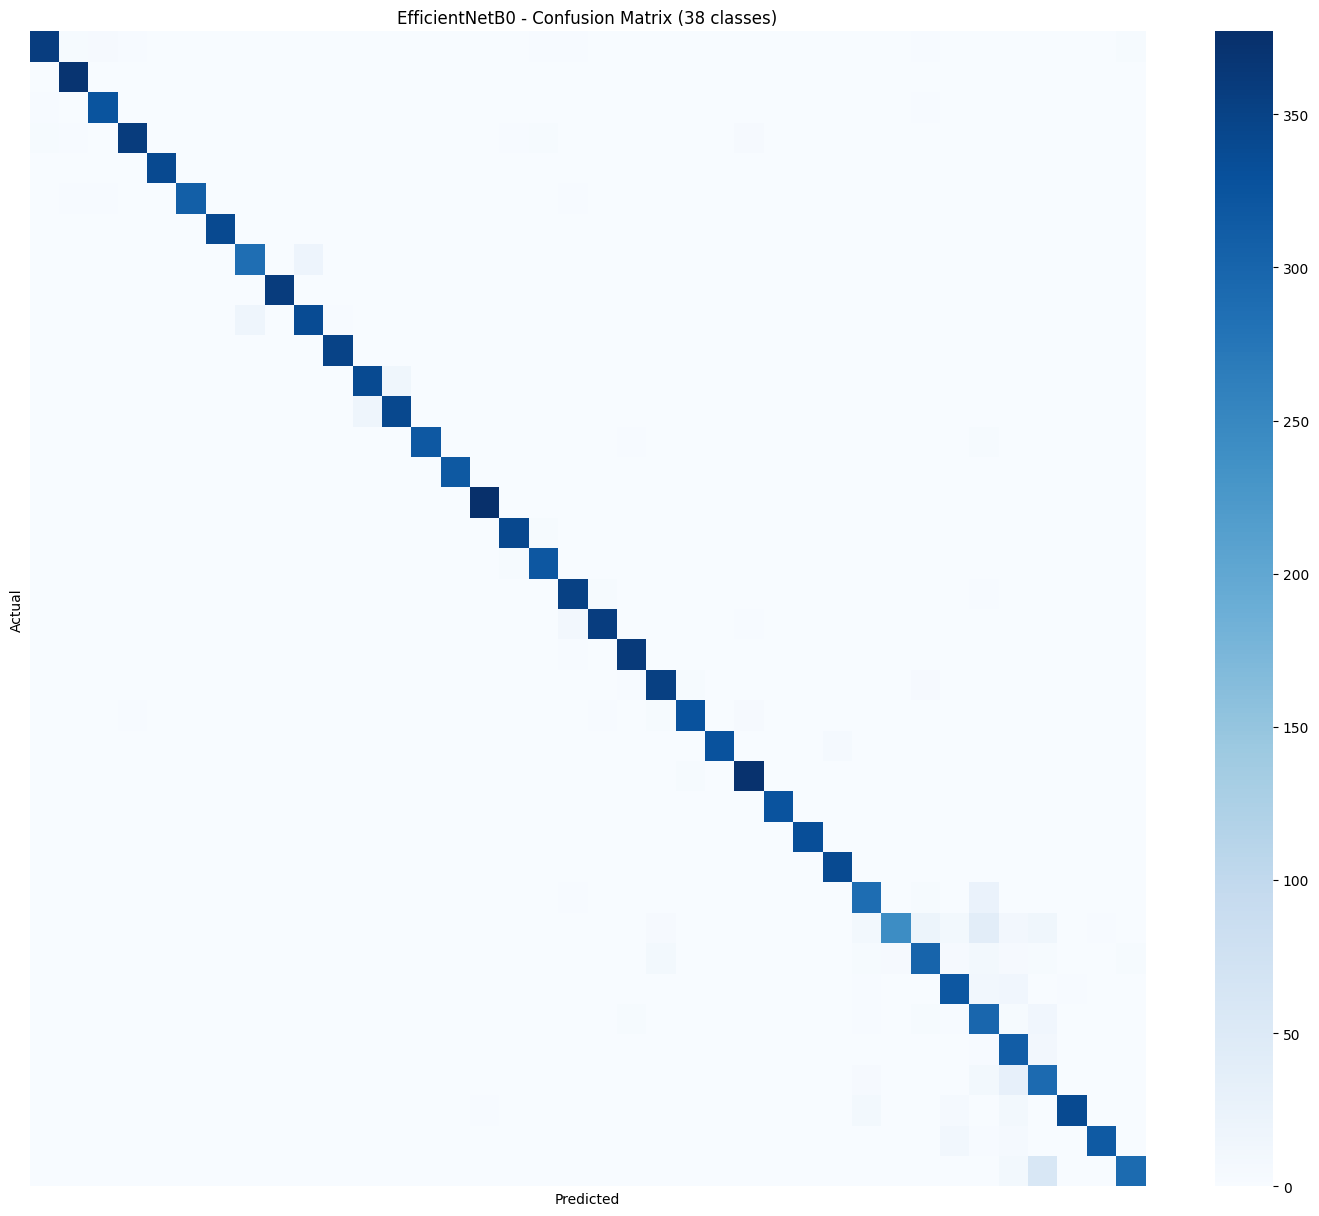

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(effnet_true_classes, effnet_pred_classes)
plt.figure(figsize = (18, 15))
sns.heatmap(cm, cmap = 'Blues', xticklabels = False, yticklabels = False)
plt.title('EfficientNetB0 - Confusion Matrix (38 classes)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('/content/drive/MyDrive/Data Science Program - HCL GUVI/Final Project - Plant disease detection/confusion_matrix_effnet.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## Hugging Face LLM integration

1. Install the client:

In [34]:
!pip install -q huggingface_hub

2. Set up the token:

In [35]:
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

3. Set up client and test:

In [36]:
from huggingface_hub import InferenceClient
client = InferenceClient(token = HF_TOKEN)
def get_treatment_recommendation(disease_name):
  clean_name = disease_name.replace("___"," - ").replace("_"," ")
  prompt = f"""Disease: {clean_name}
  Provide the following in a farmer-friendly way, using simple language:
  1. Disease Overview (1-2 sentences)
  2. Symptoms
  3. Causes
  4. Recommended Treatment
  5. Prevention Tips
  Keep each section brief and practical."""

  response = client.chat.completions.create(
      model = "Qwen/Qwen2.5-7B-Instruct",
      messages = [{"role": "user", "content": prompt}],
      max_tokens = 500,
  )
  return response.choices[0].message.content

# Test it
result = get_treatment_recommendation("Tomato___Early_blight")
print(result)

Sure, here’s a simple guide for tomato early blight:

### 1. Disease Overview
Tomato early blight is a common fungal disease that can affect tomato plants. It usually appears early in the growing season and can spread quickly if not managed.

### 2. Symptoms
- **Leaves:** Brown spots appear on the lower leaves, which then turn yellow and may fall off.
- **Fruits:** Sometimes, small brown spots can appear on the fruits.

### 3. Causes
- **Fungi:** The disease is caused by a fungus called _Bipolaris cinerea_ or _Alternaria solani_.
- **Moisture:** It thrives in warm, humid conditions and can spread through splashing water or wind.

### 4. Recommended Treatment
- **Remove Infected Parts:** Pick off and destroy any leaves or fruits that show signs of the disease.
- **Fungicides:** Use a fungicide specifically labeled for tomato early blight. Follow the instructions carefully.
- **Water Carefully:** Water at the base of the plant to keep the leaves dry.

### 5. Prevention Tips
- **Space Pla

## Save class names

In [37]:
### --- Confirm if 'train_generator' is still defined in this session ---
try:
    print(train_generator.class_indices)
except NameError:
    print("Not defined — need to rebuild it")

{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late_blight': 30, 'Tomato

Run the code below if `train_generator` is NOT defined:

In [38]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

Found 61489 images belonging to 38 classes.


Run the code below to save class names:

In [39]:
import json

class_indices = train_generator.class_indices  # {'Apple___Apple_scab': 0, ...}
idx_to_class = {v: k for k, v in class_indices.items()}  # reverse mapping

with open('/content/drive/MyDrive/Data Science Program - HCL GUVI/Final Project - Plant disease detection/class_names.json', 'w') as f:
    json.dump(idx_to_class, f)

print(f"Saved {len(idx_to_class)} class names")
print(list(idx_to_class.items())[:3])

Saved 38 class names
[(0, 'Apple___Apple_scab'), (1, 'Apple___Black_rot'), (2, 'Apple___Cedar_apple_rust')]
